In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv


# ***Imports***

In [2]:
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# ***Import dataset***

## Titanic Dataset Columns

| Column | Meaning |
|---------|---------|
| **PassengerId** | A unique identification number assigned to each passenger. |
| **Survived** | Survival status of the passenger. `0 = Did not survive`, `1 = Survived`. This is the target variable. |
| **Pclass** | Passenger class or ticket class. `1 = First Class`, `2 = Second Class`, `3 = Third Class`. |
| **Name** | Full name of the passenger. It may include titles such as Mr., Mrs., Miss, etc. |
| **Sex** | Gender of the passenger. `Male` or `Female`. |
| **Age** | Age of the passenger in years. Some values are missing (`NaN`). |
| **SibSp** | Number of siblings or spouses traveling with the passenger. |
| **Parch** | Number of parents or children traveling with the passenger. |
| **Ticket** | Ticket number assigned to the passenger. |
| **Fare** | Ticket fare paid by the passenger. |
| **Cabin** | Cabin number where the passenger stayed. Many values are missing (`NaN`). |
| **Embarked** | Port where the passenger boarded the ship. `C = Cherbourg`, `Q = Queenstown`, `S = Southampton`. |

In [3]:
data='/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv'
df=pd.read_csv(data)
df.head() # View firts five rows(instance)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# ***Part 1 — Data Exploration(EDA)***
 * **Explore dataset.**
 * Required:
   *  Number of samples
   *  Number of features
   *  Data types
   *  Missing values
   *  Duplicate values
   *  Descriptive statistics

In [4]:
# Veiw dimensions of dataset
#(Number of samples,Number of features)//(# Rows,# Columns)
df.shape

(891, 12)

In [5]:
#Data type
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [6]:
#using info to see summery of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
#Missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
#Duplicate values
df.duplicated().sum()

np.int64(0)

In [9]:
#Descriptive statistics
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
# use describe function on object dtype
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


# ***Part 2 — Feature Engineering and Preprocessing***

| Preprocessing Technique | Why It Was Applied |
|-------------------------|--------------------|
| **Missing Value Handling** | Many machine learning algorithms cannot handle missing values directly. Handling missing data improves data quality and helps produce more accurate predictions. |
| **Encoding** | Converts categorical features into numerical values because machine learning algorithms require numerical input. |
| **Scaling** | Scales numerical features to a similar range. This helps distance-based and gradient-based algorithms perform better and prevents features with large values from dominating the model. |
| **Feature Selection** | Removes irrelevant or redundant features and keeps the most informative ones, improving model performance and reducing overfitting. |
| **PCA (Optional)** | Reduces the dimensionality of the dataset while preserving most of the important information, which can improve training speed and reduce overfitting. |

#### Feature Selection

In [11]:
# Feature Selection
#remove columns ( PassengerId  and Name ) becuase its don't  provide useful information for the model or effect
df.drop(["PassengerId","Name"],axis=1,inplace=True) #axis=1 --> applied to columns 
#inplace=True -->updates the original DataFrame directly without creating a new one.

In [12]:
df.head().T

,0,1,2,3,4
Survived,0,1,1,1,0
Pclass,3,1,3,1,3
Sex,male,female,female,female,male
Age,22.0,38.0,26.0,35.0,35.0
SibSp,1,1,0,1,0
Parch,0,0,0,0,0
Ticket,A/5 21171,PC 17599,STON/O2. 3101282,113803,373450
Fare,7.25,71.2833,7.925,53.1,8.05
Cabin,NaN,C85,NaN,C123,NaN
Embarked,S,C,S,S,S


#### Missing Value Handling

In [13]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [14]:
#Calculate Missing data percentage in columns
missing_percentage=(df.isnull().sum() / len(df)) * 100
missing_percentage

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Ticket       0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64

In [15]:
#Missing values in the Embarked column are very small so removed them
df.dropna(subset=["Embarked"],inplace=True)


In [16]:
df["Embarked"].isnull().sum()

np.int64(0)

In [17]:
df["Embarked"].unique()

array(['S', 'C', 'Q'], dtype=object)

In [18]:
#Missing values in the Cabin column are very large so remove this column
df.drop(["Cabin"],axis=1,inplace=True)

In [19]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S


In [20]:
# Handle missing values in the Age column by replacing them with the mean age.
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [21]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [22]:
#checking the class distribution of target column.
df.Survived.value_counts() #imbalance

Survived
0    549
1    340
Name: count, dtype: int64

#### Encoding

In [23]:
# Identify categorical and numerical columns
cat_columns=df.select_dtypes(include="object").columns
num_columns=df.select_dtypes(include=np.number).columns
print(cat_columns,"""
*********************************************************************
""",num_columns
     )

Index(['Sex', 'Ticket', 'Embarked'], dtype='object') 
*********************************************************************
 Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


In [24]:
#Convert categorical columns to numerical columns
for column in cat_columns:
    le=LabelEncoder()
    df[column]=le.fit_transform(df[column])
df.head()    

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,1,22.0,1,0,522,7.2500,2
1,1,1,0,38.0,1,0,595,71.2833,0
2,1,3,0,26.0,0,0,668,7.9250,2
3,1,1,0,35.0,1,0,48,53.1000,2
4,0,3,1,35.0,0,0,471,8.0500,2


In [25]:
df["Ticket"].unique().sum()

np.int64(230860)

In [26]:
df.shape

(889, 9)

#### Train and Test Split

In [27]:
# Separate features and target variable
x=df.drop("Survived",axis=1)
y=df["Survived"]
x.head()

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,3,1,22.0,1,0,522,7.2500,2
1,1,0,38.0,1,0,595,71.2833,0
2,3,0,26.0,0,0,668,7.9250,2
3,1,0,35.0,1,0,48,53.1000,2
4,3,1,35.0,0,0,471,8.0500,2


In [28]:
#Split x and y into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)
print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)

Training set shape: (711, 8)
Testing set shape: (178, 8)


#### Feature Scaling

In [29]:
scaler=StandardScaler()
X_train=scaler.fit_transform(x_train)
X_test=scaler.transform(x_test)
X_train

array([[-1.58410418, -1.40530972, -0.59872878, ..., -1.5510529 ,
         2.43059683,  0.58770431],
       [ 0.8122747 , -1.40530972, -0.01594897, ..., -0.76113695,
        -0.35813533, -1.95246446],
       [ 0.8122747 ,  0.71158691,  0.16386313, ...,  1.62886513,
        -0.49094895,  0.58770431],
       ...,
       [-1.58410418, -1.40530972,  1.38401019, ..., -1.29281115,
        -0.12471679,  0.58770431],
       [ 0.8122747 , -1.40530972, -0.67498797, ...,  1.68456433,
         0.04708333,  0.58770431],
       [ 0.8122747 ,  0.71158691,  0.24012232, ...,  0.81869493,
        -0.47611594,  0.58770431]])

In [30]:
#Convert from array to Dataframe
cols=x_train.columns
X_train=pd.DataFrame(X_train,columns=[cols])
X_test=pd.DataFrame(X_test,columns=[cols])
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,-1.584104,-1.405310,-0.598729,-0.474516,-0.475644,-1.551053,2.430597,0.587704
1,0.812275,-1.405310,-0.015949,0.381780,-0.475644,-0.761137,-0.358135,-1.952464
2,0.812275,0.711587,0.163863,-0.474516,-0.475644,1.628865,-0.490949,0.587704
3,0.812275,-1.405310,-0.015949,6.375852,2.010994,1.137699,0.762595,0.587704
4,0.812275,0.711587,-1.208802,3.806964,2.010994,1.127572,0.301860,0.587704


In [31]:
X_test.head()

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0.812275,0.711587,-0.141174,-0.474516,-0.475644,-0.016793,-0.492389,0.587704
1,-1.584104,-1.405310,-1.208802,0.381780,2.010994,-1.571307,1.788823,0.587704
2,0.812275,-1.405310,-1.208802,0.381780,-0.475644,-0.796582,-0.423482,-1.952464
3,-0.385915,0.711587,0.011345,-0.474516,-0.475644,-0.599103,-0.387716,0.587704
4,-1.584104,-1.405310,-0.903766,-0.474516,2.010994,-1.728278,0.968044,0.587704


In [32]:
y_train.value_counts()#Check data balance
#Imbalance

Survived
0    440
1    271
Name: count, dtype: int64

# ***Part 3 — Train Models***

### Logistic Regression model

In [33]:
## Train a Logistic Regression model on the Training set
log_model= LogisticRegression(random_state=42)
log_model.fit(X_train,y_train)

LogisticRegression(random_state=42)

### Random Forest Model ***(Bonus)***

In [34]:
rfm=RandomForestClassifier(n_estimators=200,random_state=42) #200 Tree
rfm.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

### KNN Model

In [35]:
knnm=KNeighborsClassifier(n_neighbors=5)
knnm.fit(X_train,y_train)

KNeighborsClassifier()

# ***Part 4 — Evaluation***

In [36]:
models={
   "Logistic Regression":log_model,
   "Random Forest":rfm,
   "KNN":knnm
}
results = []

for name, model in models.items():
    y_predict = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_predict),
        "Precision": precision_score(y_test, y_predict),
        "Recall": recall_score(y_test, y_predict),
        "F1-score": f1_score(y_test, y_predict)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.792135,0.710526,0.782609,0.744828
1,Random Forest,0.803371,0.750000,0.739130,0.744526
2,KNN,0.792135,0.735294,0.724638,0.729927


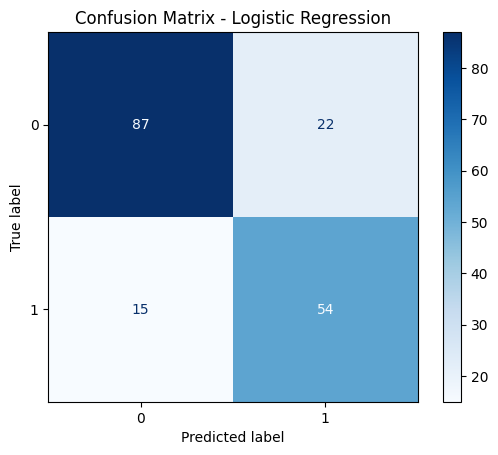

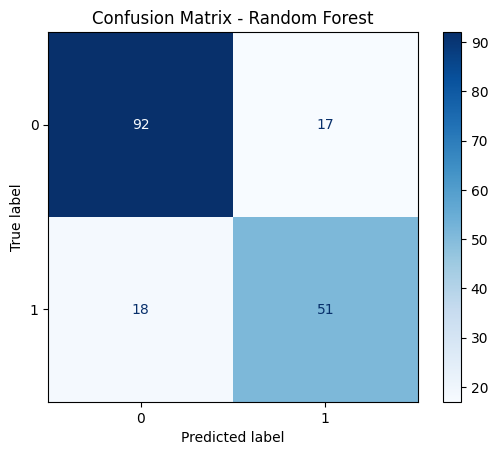

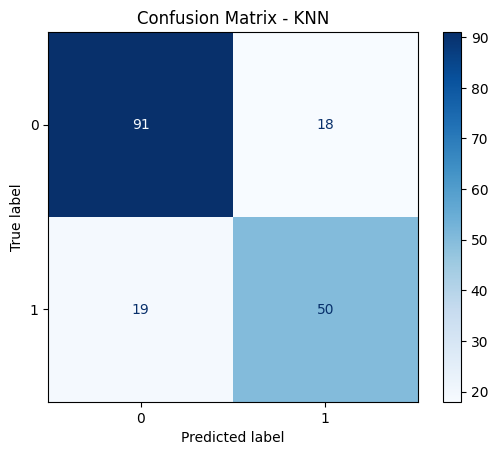

In [37]:
for name, model in models.items():
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# ***Part 5 — Clustering***

### K-Means 

In [38]:
#concatonate Two (X_train and X_test) togther instead of scaled data again
X_scaled=pd.concat([X_train , X_test], axis=0, ignore_index=True)
X_scaled.head()

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,-1.584104,-1.405310,-0.598729,-0.474516,-0.475644,-1.551053,2.430597,0.587704
1,0.812275,-1.405310,-0.015949,0.381780,-0.475644,-0.761137,-0.358135,-1.952464
2,0.812275,0.711587,0.163863,-0.474516,-0.475644,1.628865,-0.490949,0.587704
3,0.812275,-1.405310,-0.015949,6.375852,2.010994,1.137699,0.762595,0.587704
4,0.812275,0.711587,-1.208802,3.806964,2.010994,1.127572,0.301860,0.587704


In [39]:
X_scaled.shape

(889, 8)

In [40]:
# Store the results
results = []
for k in [2,3,4]:
    kmeans=KMeans(random_state=42,n_clusters=k)
    # train the model
    clusters=kmeans.fit_predict(X_scaled)
    # calculate Silhouette Score
    score = silhouette_score(X_scaled, clusters)

    # save the results
    results.append({
        "K": k,
        "Silhouette Score": score
    })

# display the comparison table
results_df = pd.DataFrame(results)
results_df

,K,Silhouette Score
0,2,0.267431
1,3,0.223594
2,4,0.232149


#### **The Best K is** ******K=2****** becuase it's Silhouette Score=Maximum Value(0.267)

# ***Part 6 — Discussion***

## Project Evaluation

### 1. Which metric is more suitable for your problem?

**F1-score** is the most suitable metric because it considers both **Precision** and **Recall**, providing a balanced evaluation of the classification model. It is more reliable than Accuracy when evaluating overall model performance.

---

### 2. Which model performed best?

**Random Forest** performed the best. It achieved the highest **Accuracy (80.34%)** and the highest **Precision (75.00%)**, while its **F1-score (74.45%)** was very close to the best value.

---

### 3. Why?

Random Forest performed better because it can capture complex relationships in the data and reduce overfitting by combining multiple decision trees. As a result, it achieved the best overall performance among the three models.

---

### 4. What preprocessing improved performance?

The preprocessing techniques that improved model performance were:

- Handling missing values.
- Encoding categorical features.
- Feature selection by removing irrelevant columns.
- Feature scaling using StandardScaler.

---

### 5. What would you do to improve the model?

To further improve the model, I would:

- Increase the number of instance  to train the model on more data; this will improve its accuracy and performance.
- Apply feature engineering to create more informative features.
- Try more advanced models such as XGBoost or LightGBM.
- Use cross-validation for a more reliable model evaluation.
- Balance data